In [51]:
from models.dncnn import DnCNN

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import importlib
import torch.nn as nn
import torch.optim as optim
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, random_split
import os
import pickle as pkl
from pytorch_msssim import ssim
from torchmetrics.image import PeakSignalNoiseRatio

In [53]:
device = torch.device('mps' if  torch.backends.mps.is_available() else 'cpu')
print(device)

mps


In [56]:
import base
importlib.reload(base)

<module 'base' from '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/base.py'>

In [57]:
from base import load_pkl, transform_1, transform_3, calc_loss, CustomData, load_data, fineTune, test_func, NoiseImage
from base import augment, test_func_batches, list_images, collect_images, augment_data


psnr_metric = PeakSignalNoiseRatio(data_range=1.0)
psnr_metric = psnr_metric.to(device)

In [47]:
dncnn_model = DnCNN().to(device)

In [48]:
for name, param in dncnn_model.named_parameters():
    print(f"{name}: require_grad = {param.requires_grad}")

layers.0.0.weight: require_grad = True
layers.0.0.bias: require_grad = True
layers.1.0.weight: require_grad = True
layers.1.0.bias: require_grad = True
layers.1.1.weight: require_grad = True
layers.1.1.bias: require_grad = True
layers.2.0.weight: require_grad = True
layers.2.0.bias: require_grad = True
layers.2.1.weight: require_grad = True
layers.2.1.bias: require_grad = True
layers.3.0.weight: require_grad = True
layers.3.0.bias: require_grad = True
layers.3.1.weight: require_grad = True
layers.3.1.bias: require_grad = True
layers.4.0.weight: require_grad = True
layers.4.0.bias: require_grad = True
layers.4.1.weight: require_grad = True
layers.4.1.bias: require_grad = True
layers.5.0.weight: require_grad = True
layers.5.0.bias: require_grad = True
layers.5.1.weight: require_grad = True
layers.5.1.bias: require_grad = True
layers.6.0.weight: require_grad = True
layers.6.0.bias: require_grad = True
layers.6.1.weight: require_grad = True
layers.6.1.bias: require_grad = True
layers.7.0.w

In [8]:
train_path = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/noisy_training.pkl'
test_path = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/noisy_testing.pkl'
noisy_training_dataset , noisy_testing_dataset = load_pkl(train_path, test_path)

In [217]:
train_dataset = CustomData(noisy_training_dataset, transform= transform_3(256 ))
test_dataset = CustomData(noisy_testing_dataset , transform = transform_3(256 ))

In [213]:
train_loader, val_loader, test_loader = load_data(train_dataset, test_dataset, batch_size = 4)

In [214]:
x_sample, y_sample = next(iter(train_loader))
print(f"x range: [{x_sample.min():.3f}, {x_sample.max():.3f}]")
print(f"y range: [{y_sample.min():.3f}, {y_sample.max():.3f}]")

x range: [0.000, 1.000]
y range: [0.000, 1.000]


# TRAAAIINNNIINGG!!!

In [249]:
fineTune(dncnn_model, train_loader , val_loader, num_epochs = 5, name='dncnn_finetuned.pth', device = device)

x range: [0.000, 1.000]
y range: [0.000, 1.000]
  Batch 10/2787 | Loss: 0.83074576292
  Batch 20/2787 | Loss: 0.55877197784
  Batch 30/2787 | Loss: 0.411556097244
  Batch 40/2787 | Loss: 0.242673648809
  Batch 50/2787 | Loss: 0.076078624893
  Batch 60/2787 | Loss: 0.0972618298855
  Batch 70/2787 | Loss: 0.0555674822076
  Batch 80/2787 | Loss: 0.085142022764
  Batch 90/2787 | Loss: 0.1134660203715
  Batch 100/2787 | Loss: 0.0330301178235
  Batch 110/2787 | Loss: 0.1139356992294
  Batch 120/2787 | Loss: 0.0861550085434
  Batch 130/2787 | Loss: 0.087128838693
  Batch 140/2787 | Loss: 0.0612187649994
  Batch 150/2787 | Loss: 0.1115547436045
  Batch 160/2787 | Loss: 0.0417377918036
  Batch 170/2787 | Loss: 0.0756198109743
  Batch 180/2787 | Loss: 0.0647367805495
  Batch 190/2787 | Loss: 0.025281734051
  Batch 200/2787 | Loss: 0.0786932869173
  Batch 210/2787 | Loss: 0.0531132605076
  Batch 220/2787 | Loss: 0.0719910561575
  Batch 230/2787 | Loss: 0.0885009235825
  Batch 240/2787 | Loss: 0.0

In [145]:
dncnn_model.load_state_dict(torch.load('/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/dncnn_finetuned.pth' , map_location = device))

<All keys matched successfully>

In [ ]:
ip_image = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/images/Red-Velvet-Mite-SEM-Image.jpg'
test_func(dncnn_model, ip_image, transform_1(), device)

TypeError: transform_1() got an unexpected keyword argument 'image'

In [62]:
ip_image = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/images/figure_03.jpg'
test_func(dncnn_model, ip_image, transform_1, device)

TypeError: transform_1() got an unexpected keyword argument 'image'

In [ ]:
fineTune(dncnn_model, train_loader , val_loader, num_epochs = 1, name='dncnn_finetuned20.pth', device = device)

In [ ]:
fineTune(dncnn_model, train_loader , val_loader, num_epochs = 150, name='dncnn_finetuned_150.pth', device = device)

x range: [0.035, 1.000]
y range: [0.035, 1.000]
  Batch 10/2787 | Loss: 0.0428374218024
  Batch 20/2787 | Loss: 0.0232955683452
  Batch 30/2787 | Loss: 0.0309747436948
  Batch 40/2787 | Loss: 0.0144214856506
  Batch 50/2787 | Loss: 0.0269176052656
  Batch 60/2787 | Loss: 0.0818278281594
  Batch 70/2787 | Loss: 0.0726526265425
  Batch 80/2787 | Loss: 0.0168257883826
  Batch 90/2787 | Loss: 0.0300139908776
  Batch 100/2787 | Loss: 0.0343786086374
  Batch 110/2787 | Loss: 0.0448792424495
  Batch 120/2787 | Loss: 0.0335238707276
  Batch 130/2787 | Loss: 0.0165899978127
  Batch 140/2787 | Loss: 0.0309419272057
  Batch 150/2787 | Loss: 0.0435374250515
  Batch 160/2787 | Loss: 0.03232179092855
  Batch 170/2787 | Loss: 0.0027443377453
  Batch 180/2787 | Loss: 0.0352350028893
  Batch 190/2787 | Loss: 0.0934544420035
  Batch 200/2787 | Loss: 0.0164474623526
  Batch 210/2787 | Loss: 0.0186554467058
  Batch 220/2787 | Loss: 0.0252887321022
  Batch 230/2787 | Loss: 0.0386004330276
  Batch 240/2787 

In [210]:
dncnn_model.load_state_dict(torch.load('/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/dncnn_finetuned_150.pth' , map_location = device))

<All keys matched successfully>

In [ ]:
ip_image = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/images/Red-Velvet-Mite-SEM-Image.jpg'
test_func(dncnn_model, ip_image, transform_1(256, train=False), device)

TypeError: 'NoneType' object is not callable

Loss: 0.00878255 | SSIM: 0.9793
PSNR: 30.6826 dB


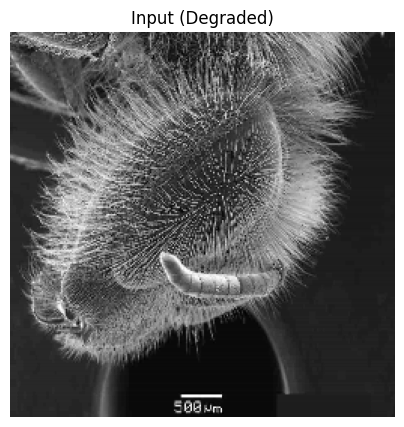

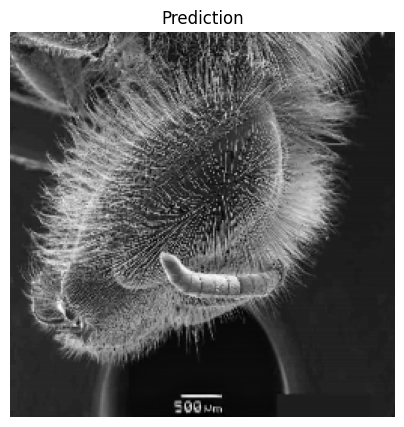

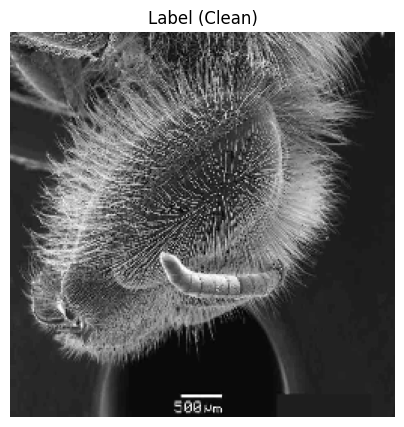

Pred Time: 0.0414, Total Time: 0.1540


In [59]:
ip_image = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/images/figure_03.jpg'
test_func(dncnn_model, ip_image, transform_1(256, False), device)

In [225]:
test_func_batches(dncnn_model , test_loader, device = 'mps')

Average Test Loss till batch: 10 = 0.09184189
Average PSNR score : 21.74012966
Average Test Loss till batch: 20 = 0.09243236
Average PSNR score : 22.02757473
Average Test Loss till batch: 30 = 0.09146460
Average PSNR score : 22.02364597
Average Test Loss till batch: 40 = 0.09248094
Average PSNR score : 22.25265722
Average Test Loss till batch: 50 = 0.09073199
Average PSNR score : 22.62245029
Average Test Loss till batch: 60 = 0.09306162
Average PSNR score : 22.51867892
Average Test Loss till batch: 70 = 0.09395943
Average PSNR score : 22.57458237
Average Test Loss till batch: 80 = 0.09442320
Average PSNR score : 22.42447486
Average Test Loss till batch: 90 = 0.09309371
Average PSNR score : 22.48218185
Average Test Loss till batch: 100 = 0.09419629
Average PSNR score : 22.54922047
Average Test Loss till batch: 110 = 0.09538147
Average PSNR score : 22.52872531
Average Test Loss till batch: 120 = 0.09543421
Average PSNR score : 22.61806971
Average Test Loss till batch: 130 = 0.09538777
Av

KeyboardInterrupt: 

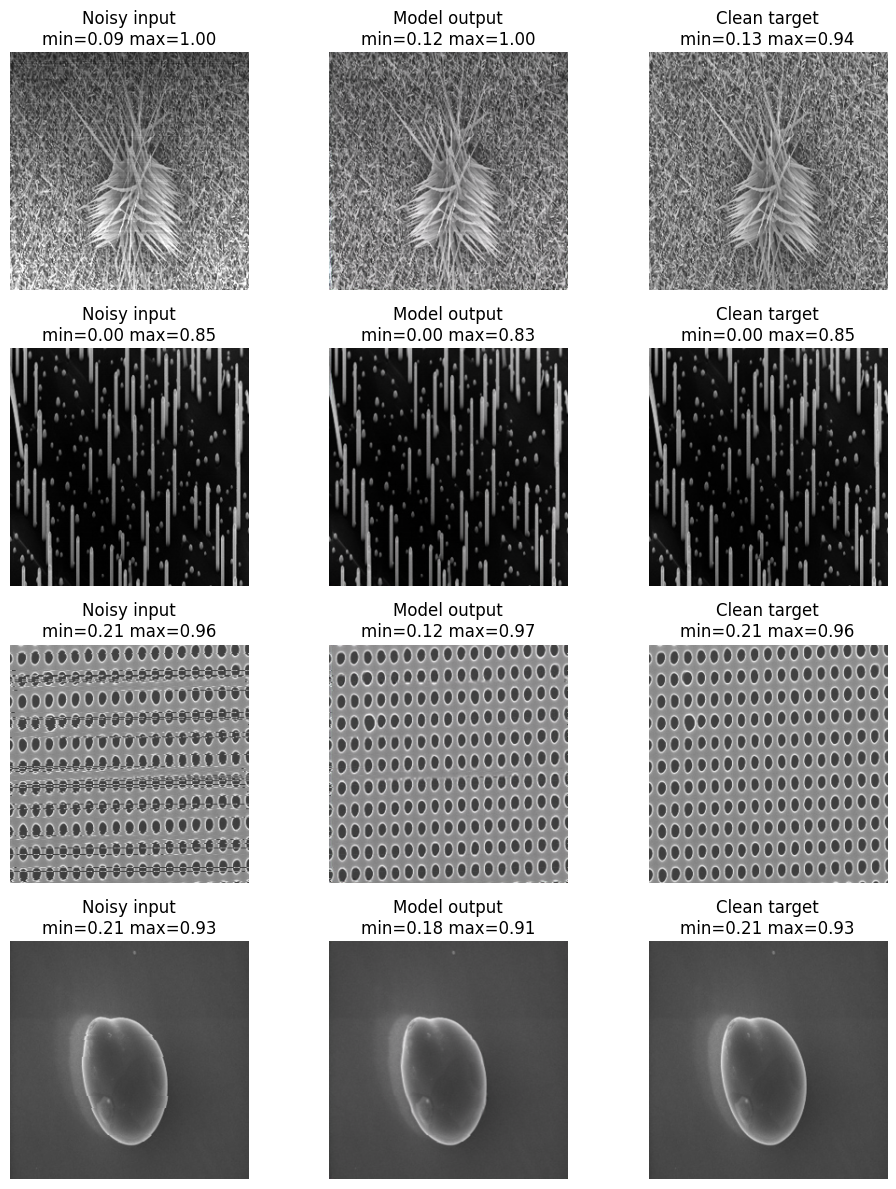

In [215]:
import matplotlib.pyplot as plt

model = dncnn_model
model.eval()
model.to(device)

xt, yt = next((iter(test_loader)))
xt, yt = xt.to(device), yt.to(device)

with torch.no_grad():
    pred = model(xt).clamp(0.0,1.0)
    # weights = torch.tensor([0.2989, 0.5870, 0.1140] , device = pred.device).view(1,3, 1, 1)
    # pred = torch.sum(pred * weights, dim=1, keepdim=True)

# Move to CPU for plotting
xt_np   = xt.cpu().numpy()
yt_np   = yt.cpu().numpy()
pred_np = pred.cpu().numpy()


# Plot first 4 images in the batch
n = min(4, xt.shape[0])
fig, axes = plt.subplots(n, 3, figsize=(10, 3*n))
for i in range(n):
    # Handle both (C,H,W) grayscale and RGB
    def to_img(t):
        img = t[i]
        if img.shape[0] == 1:
            return img[0]          # (H, W)
        return img.transpose(1,2,0)  # (H, W, C)

    axes[i, 0].imshow(to_img(xt_np),   cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f"Noisy input\nmin={xt_np[i].min():.2f} max={xt_np[i].max():.2f}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(to_img(pred_np), cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f"Model output\nmin={pred_np[i].min():.2f} max={pred_np[i].max():.2f}")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(to_img(yt_np),   cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title(f"Clean target\nmin={yt_np[i].min():.2f} max={yt_np[i].max():.2f}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()



### AUGMENT DATA AND THEN TRAIN FOR 100 EPOCHS

In [13]:
parent_dir = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/dataset/crop/images'
all_images = collect_images(parent_dir)



Total number of images collected: 18577
Shape of the first image: (299, 299, 3)
Type of the first image: <class 'numpy.ndarray'>


In [14]:
np.random.shuffle(all_images)

In [15]:
train_arrays = all_images[:int(len(all_images)*.70)]
test_arrays = all_images[int(len(all_images)*.70 ):]

In [16]:
noise_obj = NoiseImage()
train_dataset = CustomData(train_arrays, transform= transform_1(256), repeats = 5 , training = True , noise_obj = noise_obj)
test_dataset = CustomData(test_arrays , transform = transform_1(256), repeats = 1, training = False, noise_obj = noise_obj)

In [17]:
train_loader, val_loader, test_loader = load_data(train_dataset, test_dataset, batch_size = 4)

In [18]:
(x,y) = next(iter(train_loader))
x.shape

torch.Size([4, 1, 256, 256])

In [19]:
x,y = next(iter(train_loader))
x.shape
x= x.permute(0,2,3,1)

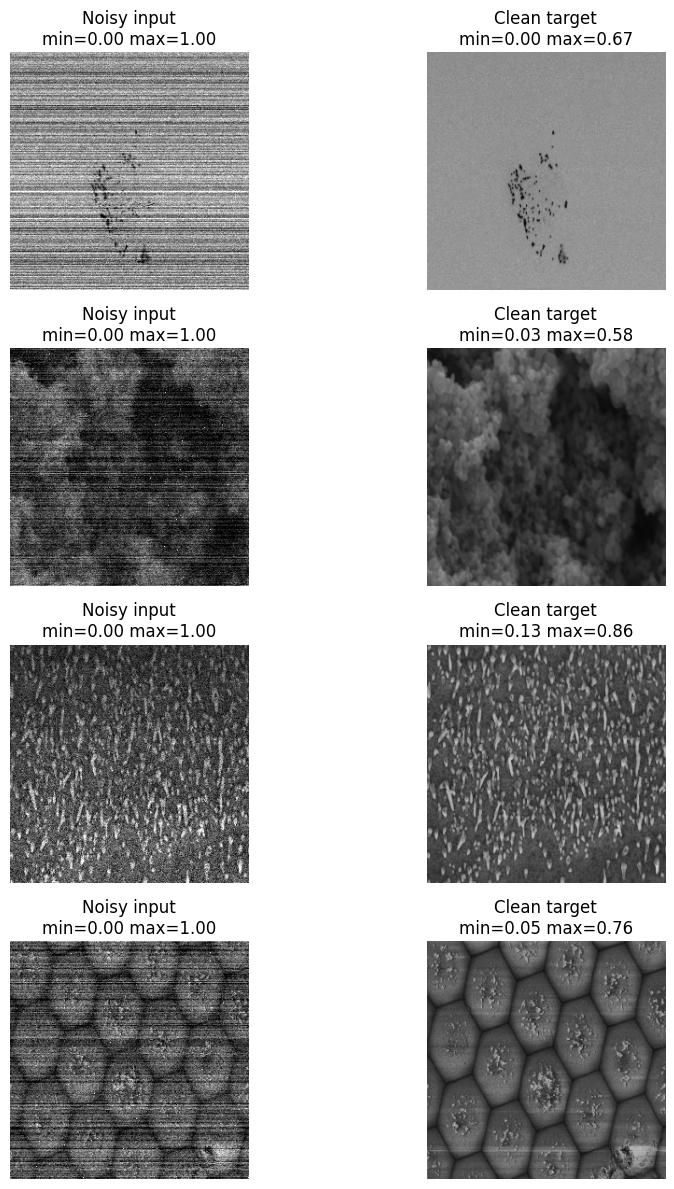

In [21]:
xt, yt = next((iter(train_loader)))
xt, yt = xt.to(device), yt.to(device)


# Move to CPU for plotting
xt_np   = xt.cpu().numpy()
yt_np   = yt.cpu().numpy()





# Plot first 4 images in the batch
n = min(4, xt.shape[0])
fig, axes = plt.subplots(n, 2, figsize=(10, 3*n))
for i in range(n):
    # Handle both (C,H,W) grayscale and RGB
    def to_img(t):
        img = t[i]
        if img.shape[0] == 1:
            return img[0]          # (H, W)
        return img.transpose(1,2,0)  # (H, W, C)

    axes[i, 0].imshow(to_img(xt_np),   cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f"Noisy input\nmin={xt_np[i].min():.2f} max={xt_np[i].max():.2f}")
    axes[i, 0].axis('off')


    axes[i, 1].imshow(to_img(yt_np),   cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f"Clean target\nmin={yt_np[i].min():.2f} max={yt_np[i].max():.2f}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()



In [22]:
device

device(type='mps')

## Training PT2

In [ ]:
fineTune(dncnn_model, train_loader , val_loader, num_epochs = 20, name='dncnn_finetuned_20_augData_2.pth',save_freq = 2, metric = 'dists' , device = device)

x range: [0.000, 1.000]
y range: [0.000, 0.999]
  Batch 10/13003 | Loss: 0.48813683 
 PSNR: 3.1545612812042236
  Batch 20/13003 | Loss: 0.40977585 
 PSNR: 5.0089521408081055
  Batch 30/13003 | Loss: 0.27663618 
 PSNR: 7.3783650398254395


In [16]:
dncnn_model.load_state_dict(torch.load('dncnn_finetuned_20_augData.pth' , map_location=device))

<All keys matched successfully>

In [17]:
test_func_batches(dncnn_model, test_loader, device = 'mps')

Average Test Loss till batch: 10 = 0.13075891
Average PSNR score : 23.81338520
Average Test Loss till batch: 20 = 0.12827503
Average PSNR score : 23.91546907
Average Test Loss till batch: 30 = 0.13136804
Average PSNR score : 23.64804923
Average Test Loss till batch: 40 = 0.12916078
Average PSNR score : 23.92475414
Average Test Loss till batch: 50 = 0.12597339
Average PSNR score : 23.84023212
Average Test Loss till batch: 60 = 0.12611823
Average PSNR score : 23.81334750
Average Test Loss till batch: 70 = 0.12722671
Average PSNR score : 24.08743758
Average Test Loss till batch: 80 = 0.12642049
Average PSNR score : 24.12764082
Average Test Loss till batch: 90 = 0.12687601
Average PSNR score : 24.05258789
Average Test Loss till batch: 100 = 0.12833011
Average PSNR score : 24.07441607
Average Test Loss till batch: 110 = 0.12912371
Average PSNR score : 24.01033818
Average Test Loss till batch: 120 = 0.12941641
Average PSNR score : 23.87452434
Average Test Loss till batch: 130 = 0.12963619
Av

In [ ]:
fineTune(dncnn_model, train_loader , val_loader, num_epochs = 20, name='dncnn_finetuned_20_augData_2.pth',save_freq = 1,metric = 'dists', device = device)

x range: [0.000, 1.000]
y range: [0.084, 1.000]
  Batch 10/13003 | Loss: 0.06576155 18
 PSNR: 23.501340866088867
  Batch 20/13003 | Loss: 0.16679156 04
 PSNR: 20.257919311523438
  Batch 30/13003 | Loss: 0.11620533 52
 PSNR: 26.49665641784668
  Batch 40/13003 | Loss: 0.10160169 82
 PSNR: 26.447498321533203
  Batch 50/13003 | Loss: 0.10998966 02
 PSNR: 27.27703285217285
  Batch 60/13003 | Loss: 0.09048402 25
 PSNR: 22.92202377319336
  Batch 70/13003 | Loss: 0.08026662 17
 PSNR: 24.734699249267578
  Batch 80/13003 | Loss: 0.16693318 36
 PSNR: 24.173368453979492
  Batch 90/13003 | Loss: 0.08119684 71
 PSNR: 28.116100311279297
  Batch 100/13003 | Loss: 0.11251177 9
 PSNR: 26.923118591308594
  Batch 110/13003 | Loss: 0.09873774 48
 PSNR: 26.144533157348633
  Batch 120/13003 | Loss: 0.13239661 76
 PSNR: 22.342041015625
  Batch 130/13003 | Loss: 0.03904333 817
 PSNR: 30.227842330932617
  Batch 140/13003 | Loss: 0.13331605 73
 PSNR: 25.850866317749023
  Batch 150/13003 | Loss: 0.08350044 69
 PS

In [ ]:
fineTune(dncnn_model, train_loader , val_loader, num_epochs = 20, name='dncnn_finetuned_20_augData_2.pth',save_freq = 2, metric = 'dists' , device = device)

x range: [0.000, 1.000]
y range: [0.000, 0.985]
  Batch 10/13003 | Loss: 0.45324749 
 PSNR: 3.4699864387512207
  Batch 20/13003 | Loss: 0.33866355 
 PSNR: 5.996751308441162
  Batch 30/13003 | Loss: 0.32406712 
 PSNR: 7.942353248596191
  Batch 40/13003 | Loss: 0.26322228 
 PSNR: 10.91345500946045
  Batch 50/13003 | Loss: 0.21706738 
 PSNR: 12.42922306060791
  Batch 60/13003 | Loss: 0.25604382 
 PSNR: 14.894661903381348
  Batch 70/13003 | Loss: 0.23405451 
 PSNR: 14.192615509033203
  Batch 80/13003 | Loss: 0.22981310 
 PSNR: 16.09864044189453
  Batch 90/13003 | Loss: 0.21670088 
 PSNR: 16.29900360107422
  Batch 100/13003 | Loss: 0.18734163 
 PSNR: 16.450597763061523
  Batch 110/13003 | Loss: 0.21073890 
 PSNR: 17.466758728027344
  Batch 120/13003 | Loss: 0.18718430 
 PSNR: 18.956928253173828
  Batch 130/13003 | Loss: 0.19110060 
 PSNR: 17.158645629882812
  Batch 140/13003 | Loss: 0.22639532 
 PSNR: 16.8489933013916
  Batch 150/13003 | Loss: 0.22126606 
 PSNR: 18.288150787353516
  Batch 1

TypeError: unsupported format string passed to Tensor.__format__

In [ ]:
fineTune(dncnn_model, train_loader , val_loader, num_epochs = 20,theta = 0.75, name='dncnn_finetuned_20_augData_2.pth',save_freq = 2, metric = 'dists' , device = device)

x range: [0.000, 1.000]
y range: [0.000, 0.892]
  Batch 10/13003 | Loss: nan 
 PSNR: nan
  Batch 20/13003 | Loss: nan 
 PSNR: nan
